In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('./jabodetabek_house_price.csv')
df.head()

,url,price_in_rp,title,address,district,city,lat,long,facilities,property_type,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,https://www.rumah123.com/properti/bekasi/hos11...,2.990000e+09,Rumah cantik Sumarecon Bekasi\nLingkungan asri...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Tempat Jemuran, Jalur Telepon, Taman, Taman",rumah,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,https://www.rumah123.com/properti/bekasi/hos10...,1.270000e+09,"Rumah Kekinian, Magenta Summarecon Bekasi","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,Taman,rumah,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,https://www.rumah123.com/properti/bekasi/hos10...,1.950000e+09,Rumah Cantik 2 Lantai Cluster Bluebell Summare...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Masjid, Taman,...",rumah,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,https://www.rumah123.com/properti/bekasi/hos10...,3.300000e+09,Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jalur Telepon, Jogging Track, Track Lari, K...",rumah,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,https://www.rumah123.com/properti/bekasi/hos10...,4.500000e+09,"Rumah Hoek di Cluster Maple Summarecon Bekasi,...","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Taman, Jalur Te...",rumah,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


In [3]:
df.isnull().sum()

url                        0
price_in_rp                0
title                      0
address                    0
district                   0
city                       0
lat                        0
long                       0
facilities                 0
property_type              1
ads_id                     4
bedrooms                  34
bathrooms                 29
land_size_m2               2
building_size_m2           2
carports                   0
certificate              141
electricity                0
maid_bedrooms              0
maid_bathrooms             0
floors                     6
building_age            1445
year_built              1445
property_condition       246
building_orientation    1647
garages                    0
furnishing               387
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   3553 non-null   object 
 1   price_in_rp           3553 non-null   float64
 2   title                 3553 non-null   object 
 3   address               3553 non-null   object 
 4   district              3553 non-null   object 
 5   city                  3553 non-null   object 
 6   lat                   3553 non-null   float64
 7   long                  3553 non-null   float64
 8   facilities            3553 non-null   object 
 9   property_type         3552 non-null   object 
 10  ads_id                3549 non-null   object 
 11  bedrooms              3519 non-null   float64
 12  bathrooms             3524 non-null   float64
 13  land_size_m2          3551 non-null   float64
 14  building_size_m2      3551 non-null   float64
 15  carports             

In [5]:
df.describe()

,price_in_rp,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,garages
count,3.553000e+03,3553.000000,3553.000000,3519.000000,3524.000000,3551.000000,3551.000000,3553.000000,3553.000000,3553.000000,3547.000000,2108.000000,2108.000000,3553.000000
mean,4.191685e+09,-6.324721,106.792881,3.326513,2.624858,204.806815,186.587440,1.197861,0.496482,0.370391,1.764590,3.880930,2018.137097,0.708978
std,1.375067e+10,0.129245,0.172159,2.672148,2.696497,402.127746,248.443471,1.114996,0.685723,0.536024,0.637349,7.603708,7.641448,1.311879
min,4.200000e+07,-6.894828,106.402315,1.000000,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1870.000000,0.000000
25%,8.000000e+08,-6.397933,106.687295,2.000000,2.000000,75.000000,65.500000,1.000000,0.000000,0.000000,1.000000,0.000000,2016.000000,0.000000
50%,1.500000e+09,-6.300733,106.799954,3.000000,2.000000,108.000000,112.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2021.000000,0.000000
75%,3.590000e+09,-6.231754,106.874766,4.000000,3.000000,192.000000,208.000000,2.000000,1.000000,1.000000,2.000000,6.000000,2022.000000,1.000000
max,5.800000e+11,-6.102478,109.771691,99.000000,99.000000,8000.000000,6000.000000,15.000000,7.000000,5.000000,5.000000,152.000000,2052.000000,50.000000


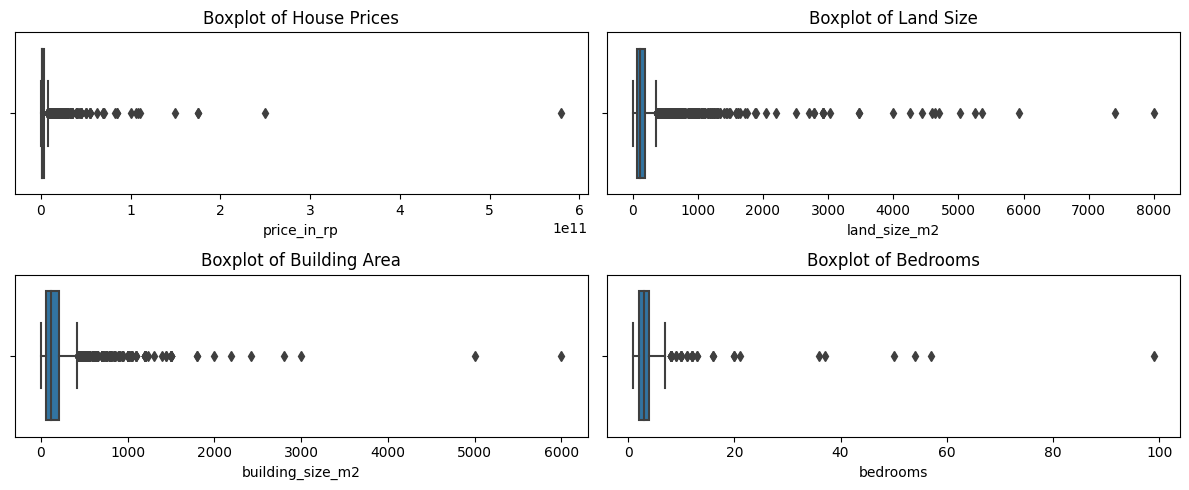

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5))

sns.boxplot(x=df['price_in_rp'], ax=ax[0][0])
ax[0][0].set_title('Boxplot of House Prices')

sns.boxplot(x=df['land_size_m2'], ax=ax[0][1])
ax[0][1].set_title('Boxplot of Land Size')

sns.boxplot(x=df['building_size_m2'], ax=ax[1][0])
ax[1][0].set_title('Boxplot of Building Area')

sns.boxplot(x=df['bedrooms'], ax=ax[1][1])
ax[1][1].set_title('Boxplot of Bedrooms')   
plt.tight_layout()
plt.show()


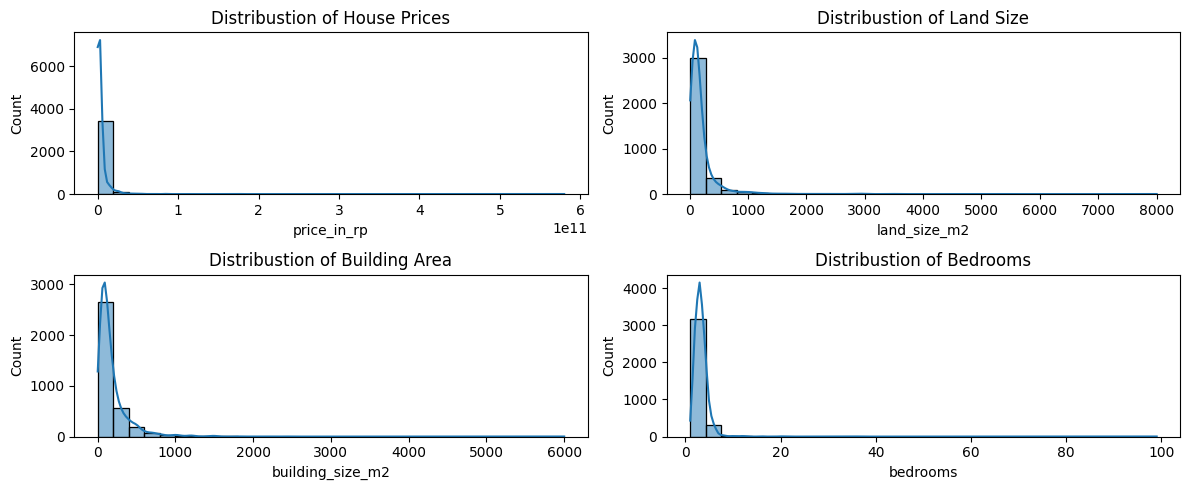

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5))

sns.histplot(df['price_in_rp'], bins=30, kde=True, ax=ax[0][0])
ax[0][0].set_title("Distribustion of House Prices")

sns.histplot(df['land_size_m2'], bins=30, kde=True, ax=ax[0][1])
ax[0][1].set_title("Distribustion of Land Size")

sns.histplot(df['building_size_m2'], bins=30, kde=True, ax=ax[1][0])
ax[1][0].set_title("Distribustion of Building Area")

sns.histplot(df['bedrooms'], bins=30, kde=True, ax=ax[1][1])
ax[1][1].set_title("Distribustion of Bedrooms")

plt.tight_layout()
plt.show()

Preprocessing Data

In [8]:
feature = ['city', 'certificate', 'land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms', 'garages', 'carports', 'price_in_rp']

df = df[feature]

In [9]:
df = df.dropna(subset=['price_in_rp'])

In [10]:
def remove_outliers_iqr(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_out= df_out[
            (df_out[col] >= lower) &
            (df_out[col] <= upper)
        ]

    return df_out

df = remove_outliers_iqr(df, ['price_in_rp', 'land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms', 'garages', 'carports'])

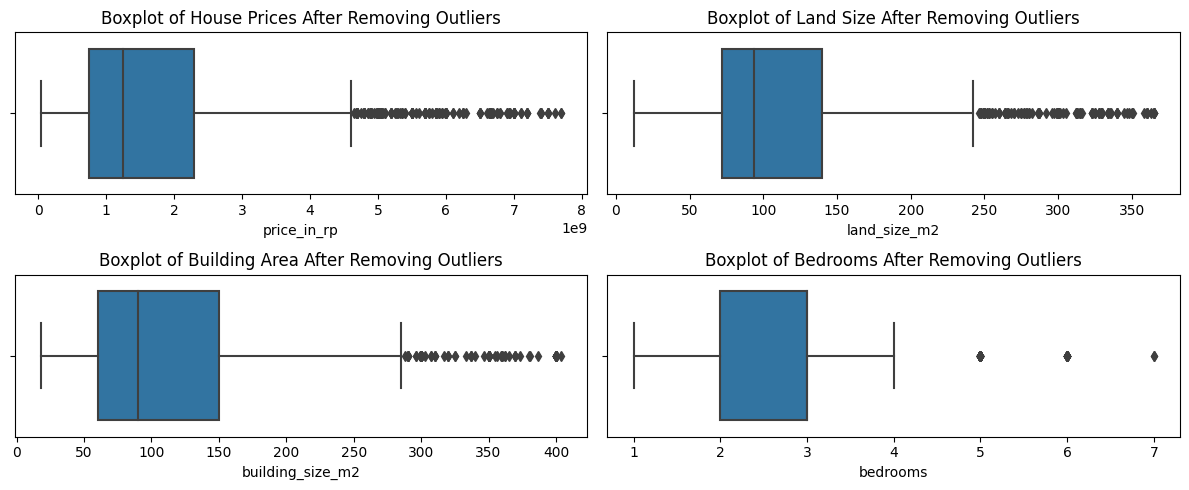

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5))

sns.boxplot(x=df['price_in_rp'], ax=ax[0][0])
ax[0][0].set_title('Boxplot of House Prices After Removing Outliers')

sns.boxplot(x=df['land_size_m2'], ax=ax[0][1])
ax[0][1].set_title('Boxplot of Land Size After Removing Outliers')

sns.boxplot(x=df['building_size_m2'], ax=ax[1][0])
ax[1][0].set_title('Boxplot of Building Area After Removing Outliers')

sns.boxplot(x=df['bedrooms'], ax=ax[1][1])
ax[1][1].set_title('Boxplot of Bedrooms After Removing Outliers')   
plt.tight_layout()
plt.show()

In [12]:
y = np.log1p(df['price_in_rp']) 

df['land_size_m2'] = np.log1p(df['land_size_m2'])
df['building_size_m2'] = np.log1p(df['building_size_m2'])

X = df.drop('price_in_rp', axis=1)

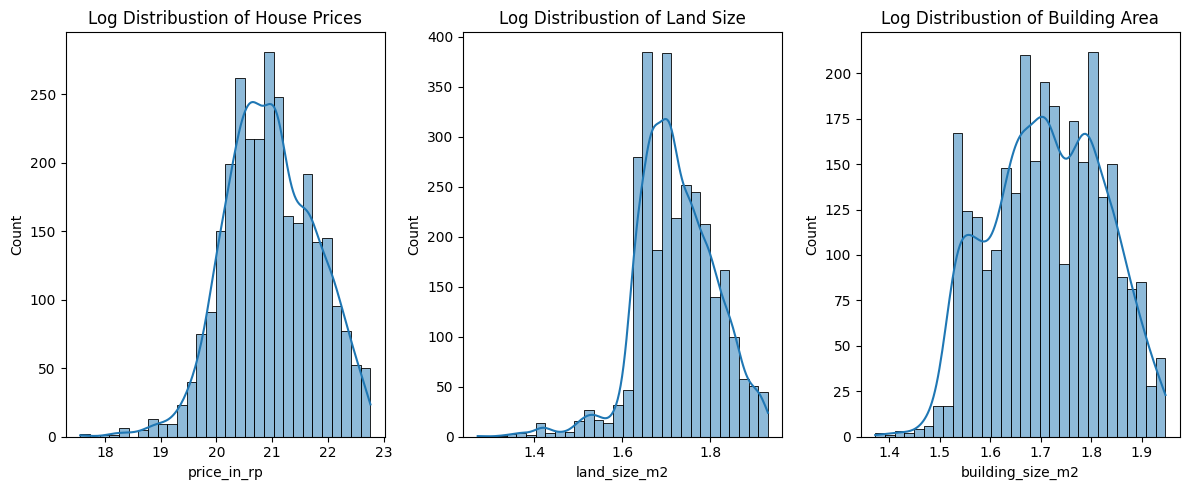

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.histplot(np.log1p(df['price_in_rp']), bins=30, kde=True, ax=ax[0])
ax[0].set_title("Log Distribustion of House Prices")

sns.histplot(np.log1p(df['land_size_m2']), bins=30, kde=True, ax=ax[1])
ax[1].set_title("Log Distribustion of Land Size")

sns.histplot(np.log1p(df['building_size_m2']), bins=30, kde=True, ax=ax[2])
ax[2].set_title("Log Distribustion of Building Area")

plt.tight_layout()
plt.show()

Pembagian Data (80:20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
numeric_features = ['land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms', 'garages', 'carports']
categorical_features = ['city', 'certificate']

In [16]:
for col in numeric_features:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [17]:
for col in categorical_features:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

X_train = pd.get_dummies(X_train, columns=categorical_features, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_features, dtype=int)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [19]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [20]:
def evaluate_model(name, model, X_test, y_test):
    y_pred_log = model.predict(X_test)
    
    # Kembalikan ke skala harga asli (Rupiah)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_real, y_pred_real)
    
    mean_price = np.mean(y_test_real)
    mae_percentage = (mae / mean_price) * 100
    
    print(f"--- {name} ---")
    print(f"MAE: Rp {mae:,.2f} (~{mae_percentage:.2f}%)")
    print(f"RMSE: Rp {rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate_model("Linear Regression", lr_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)

--- Linear Regression ---
MAE: Rp 421,199,867.44 (~25.14%)
RMSE: Rp 648,327,939.80
R2 Score: 0.7769

--- Random Forest ---
MAE: Rp 305,667,441.42 (~18.24%)
RMSE: Rp 532,110,175.25
R2 Score: 0.8497



In [21]:

joblib.dump(rf_model, 'model_harga_rumah.pkl')

joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("Model dan struktur kolom berhasil disimpan pakai Joblib!")

Model dan struktur kolom berhasil disimpan pakai Joblib!
